# Optimisers

### SGD, Momentum, RMSProp, Adam: what each one actually fixes

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The specific failure each optimiser was invented to fix, how they differ on a surface you can see, and whether adaptive methods find better minima or merely reach them sooner |
| **You should already know** | [The PyTorch training loop](../03-the-same-net-in-pytorch/) |
| **Datasets** | A 2-D loss surface, then Fashion-MNIST |
| **Runtime** | About fifteen minutes end to end. The four 8-epoch runs in section 4 are 526 s of that, measured on torch 2.11.0 with CUDA |
| **Next** | [07-06 Regularisation](../06-regularisation/) |

---

## 1. The problem with plain gradient descent

Gradient descent takes a step downhill proportional to the slope:

$$w \leftarrow w - \eta \nabla L$$

$w$ is a weight, $\nabla L$ is the slope of the loss with respect to that weight,
and $\eta$ is the learning rate, the one number deciding how far each step goes.

It fails in two specific ways, and every optimiser after it is a fix for one of
them.

**Ravines.** When the loss surface is much steeper in one direction than another,
the gradient points mostly across the valley rather than along it. The textbook
account says the optimiser bounces between the walls and creeps toward the
minimum. Ravines are the normal case, not an exotic one: they appear whenever
features are correlated or on different scales.

**One learning rate for every parameter.** A rate small enough to be safe for the
steepest direction is far too small for the flattest, so the flat directions
barely move.

Those two failures are usually told as one story. Section 3 draws the surface and
counts what each optimiser actually does on it, and the count does not match the
story, which turns out to be the most useful thing in this notebook.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")

torch 2.11.0+cu128 on cuda


## 2. The four updates

**SGD** moves along the gradient.

**Momentum** accumulates a running average of past gradients and moves along
that. Consistent directions build up speed; directions that keep flipping sign
cancel out. It is a ball rolling downhill instead of a walker re-deciding at
every step.

$$v \leftarrow \beta v + \nabla L \qquad w \leftarrow w - \eta v$$

$v$ is the velocity, the running total of past gradients, and $\beta$ is how much
of it survives each step, usually 0.9. The weight then moves along $v$ rather
than along the raw gradient.

**RMSProp** keeps a running average of the *squared* gradient per parameter and
divides the step by its square root. Parameters with consistently large gradients
get smaller steps, flat ones get larger. This is a per-parameter learning rate.

$$s \leftarrow \gamma s + (1-\gamma)(\nabla L)^2 \qquad w \leftarrow w - \frac{\eta}{\sqrt{s} + \epsilon}\nabla L$$

$s$ is that running average of squared gradients, $\gamma$ decides how long its
memory is, and $\epsilon$ is a tiny constant that keeps the division safe when
$s$ is near zero.

**Adam** is both at once: momentum on the gradient, RMSProp on its square, plus a
bias correction because both averages start at zero and are therefore wrong early on.

## 3. Watching them on a ravine

           final loss  distance  along flat  along steep  crossings
SGD          0.134093    1.6376      1.6376       0.0000          0
Momentum     0.011805    0.3918      0.3862       0.0659         15
RMSProp      0.009567    0.0978      0.0002       0.0978         14
Adam         0.009721    0.4345      0.4341       0.0173          5

at lr = 0.28, SGD multiplies the steep coordinate by 0.44 every step, and the flat one by 0.972
a positive multiplier cannot change sign, so SGD cannot oscillate at this rate
oscillating in the steep direction needs lr > 1 / curvature = 0.5
momentum's steady-state step is lr / (1 - beta) = 2.8, and 2.8 x curvature 2 = 5.6
the heavy-ball stability limit is 2(1 + beta) = 3.8, so momentum is the one running unstable in the steep direction


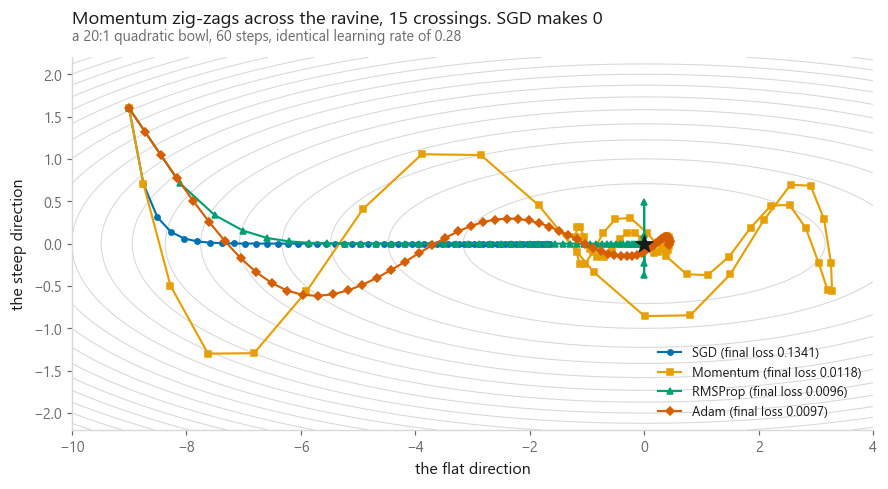

In [2]:
# A quadratic bowl stretched 20:1 -- the classic ravine.
def surface(x, y):
    return 0.05 * x ** 2 + y ** 2


def gradient(x, y):
    return np.array([0.1 * x, 2 * y])


def run(kind, steps=60, lr=0.28, start=(-9.0, 1.6)):
    w = np.array(start, dtype=float)
    path = [w.copy()]
    v = np.zeros(2)
    s = np.zeros(2)
    m = np.zeros(2)
    for t in range(1, steps + 1):
        g = gradient(*w)
        if kind == "SGD":
            step = lr * g
        elif kind == "Momentum":
            v = 0.9 * v + g
            step = lr * v
        elif kind == "RMSProp":
            s = 0.9 * s + 0.1 * g ** 2
            step = lr * g / (np.sqrt(s) + 1e-8)
        else:  # Adam
            m = 0.9 * m + 0.1 * g
            s = 0.999 * s + 0.001 * g ** 2
            step = lr * (m / (1 - 0.9 ** t)) / (np.sqrt(s / (1 - 0.999 ** t)) + 1e-8)
        w = w - step
        path.append(w.copy())
    return np.array(path)


grid_x, grid_y = np.meshgrid(np.linspace(-10, 4, 300), np.linspace(-2.2, 2.2, 300))
paths = {k: run(k) for k in ["SGD", "Momentum", "RMSProp", "Adam"]}


def valley_crossings(path):
    """How many times the path changes sign in the steep direction.

    This is what "zig-zagging across the ravine" means, counted rather than
    eyeballed.
    """
    signs = np.sign(path[:, 1][np.abs(path[:, 1]) > 1e-9])
    return int((np.diff(signs) != 0).sum())


crossings = {name: valley_crossings(p) for name, p in paths.items()}
bounciest = max(crossings, key=crossings.get)
calmest = min(crossings, key=crossings.get)

fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.contour(grid_x, grid_y, surface(grid_x, grid_y), levels=22,
           colors=[style.RULE], linewidths=0.7)
for i, (name, path) in enumerate(paths.items()):
    ax.plot(path[:, 0], path[:, 1], marker=style.MARKERS[i], ms=3.5, lw=1.4,
            color=style.PALETTE[i], label=f"{name} (final loss {surface(*path[-1]):.4f})")
ax.scatter([0], [0], s=140, marker="*", c=style.INK, zorder=6)
ax.set_xlabel("the flat direction")
ax.set_ylabel("the steep direction")
ax.grid(False)
ax.legend(fontsize=8.5, loc="lower right")
style.title(ax,
            f"{bounciest} zig-zags across the ravine, {crossings[bounciest]} crossings. "
            f"{calmest} makes {crossings[calmest]}",
            "a 20:1 quadratic bowl, 60 steps, identical learning rate of 0.28")
style.save(fig, FIG / "fig-01-ravine.png")

print(f"{'':<9} {'final loss':>11} {'distance':>9} {'along flat':>11} "
      f"{'along steep':>12} {'crossings':>10}")
for name, path in paths.items():
    print(f"{name:<9} {surface(*path[-1]):>11.6f} {np.linalg.norm(path[-1]):>9.4f} "
          f"{abs(path[-1, 0]):>11.4f} {abs(path[-1, 1]):>12.4f} {crossings[name]:>10}")

# Why SGD behaves the way it does here, straight from the update rule.
LR, BETA = 0.28, 0.9
print(f"\nat lr = {LR}, SGD multiplies the steep coordinate by "
      f"{1 - LR * 2:.2f} every step, and the flat one by {1 - LR * 0.1:.3f}")
print("a positive multiplier cannot change sign, so SGD cannot oscillate at this rate")
print(f"oscillating in the steep direction needs lr > 1 / curvature = {1 / 2:.1f}")
print(f"momentum's steady-state step is lr / (1 - beta) = {LR / (1 - BETA):.1f}, and "
      f"{LR / (1 - BETA):.1f} x curvature 2 = {LR / (1 - BETA) * 2:.1f}")
print(f"the heavy-ball stability limit is 2(1 + beta) = {2 * (1 + BETA):.1f}, so momentum "
      f"is the one running unstable in the steep direction")

**This is not the picture the textbook led me to expect, including the one I
wrote three cells ago.** Look at the blue line before reading anything else. SGD
drops onto the valley floor in about half a dozen steps and then creeps along it
at y of essentially zero. It crosses the floor **0** times. The path that swings
high above the floor, dives below it, and overshoots the minimum out past the
star on the far side is **momentum**, with 15 crossings.

The classic zig-zag is real, and at this learning rate it belongs to the wrong
optimiser. The arithmetic says why, and it is two lines.

The steep direction has curvature 2, so SGD's update there is
$y \leftarrow y - 0.28 \cdot 2y = 0.44y$. A **positive** multiplier under one is
a monotone contraction: it shrinks $y$ toward zero and can never flip its sign.
SGD physically cannot oscillate on this surface at this rate. Zig-zagging needs
$\eta > 1/\text{curvature}$, so it would need a rate above 0.5 here, and 0.28 is
not it.

The flat direction has curvature 0.1, so the same rate gives
$x \leftarrow 0.972x$, and sixty of those steps get the starting $-9$ only as far
as the printed 1.6376. That is the whole of SGD's final distance: the
printed 1.6376 is 1.6376 of flat and 0.0000 of steep. **SGD's loss is high
because it never crossed the
valley, not because it spent its steps crossing it.** It is slow, not bouncy.

Momentum is the unstable one. Its velocity is $v \leftarrow 0.9v + g$, so at
steady state the effective step is $\eta/(1-\beta) = 2.8$, and 2.8 times the
curvature of 2 is 5.6, past the heavy-ball stability limit of $2(1+\beta) = 3.8$.
It overshoots, reverses, overshoots less, and spirals in. That it still lands at
a **lower** loss than SGD is the actual finding: an oscillating optimiser that
covers ground beats a stable one that barely moves.

RMSProp is SGD's mirror image, and the printed table shows it cleanly. It
finishes 0.0002 from the minimum along the flat direction and 0.0978 along the
steep one, so essentially all of its remaining error is in the direction where
SGD had none. Dividing by the running root-mean-square gradient makes the flat
direction move at full speed and leaves a little jitter in the steep one. Adam
splits the difference, 5 crossings, and finishes further out than momentum
(0.4345 against 0.3918) at a **lower** loss, because what is left of its error
lies along the cheap flat axis. Distance and loss are different rulers on a
stretched surface.

The honest version of the ravine lesson, then: **the classic picture depends on a
learning rate large enough for the steep direction to oscillate.** Pick one below
that threshold and plain gradient descent does not zig-zag at all, it simply
crawls, and the failure you actually get is the slow flat direction rather than
the bouncing steep one. Both are the same underlying problem, one rate for two
very different curvatures, and both are what the adaptive methods fix.

## 4. On a real network

The 2-D picture is a good intuition and a bad prediction. Real loss surfaces have
millions of dimensions, and the ordering can change.

In [3]:
from torch.utils.data import DataLoader

train_set = datasets.fashion_mnist(train=True)
test_set = datasets.fashion_mnist(train=False)
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000)


def build():
    torch.manual_seed(SEED)
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128), nn.ReLU(),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 10),
    ).to(device)


def train(optimiser_name, epochs=8):
    model = build()
    loss_fn = nn.CrossEntropyLoss()
    makers = {
        "SGD": lambda p: torch.optim.SGD(p, lr=0.05),
        "Momentum": lambda p: torch.optim.SGD(p, lr=0.05, momentum=0.9),
        "RMSProp": lambda p: torch.optim.RMSprop(p, lr=0.001),
        "Adam": lambda p: torch.optim.Adam(p, lr=0.001),
    }
    optimiser = makers[optimiser_name](model.parameters())

    history = {"train_loss": [], "test_acc": []}
    for _ in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimiser.step()
            running += loss.item() * len(xb)
        history["train_loss"].append(running / len(train_set))

        model.eval()
        correct = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                correct += (model(xb.to(device)).argmax(1) == yb.to(device)).sum().item()
        history["test_acc"].append(correct / len(test_set))
    return history


results = {}
for name in ["SGD", "Momentum", "RMSProp", "Adam"]:
    started = time.perf_counter()
    results[name] = train(name)
    results[name]["seconds"] = time.perf_counter() - started
    print(f"{name:<9}: final test accuracy {results[name]['test_acc'][-1]:.4f}  "
          f"({results[name]['seconds']:.0f} s)")

SGD      : final test accuracy 0.8317  (95 s)


Momentum : final test accuracy 0.8745  (89 s)


RMSProp  : final test accuracy 0.8662  (76 s)


Adam     : final test accuracy 0.8672  (84 s)


          final train loss  best test accuracy  final test accuracy  epochs to reach 0.85  seconds
SGD                 0.4496              0.8317               0.8317                   NaN  95.0621
Momentum            0.2956              0.8745               0.8745                   5.0  89.4327
RMSProp             0.3065              0.8662               0.8662                   5.0  76.4962
Adam                0.3091              0.8692               0.8672                   3.0  84.0143


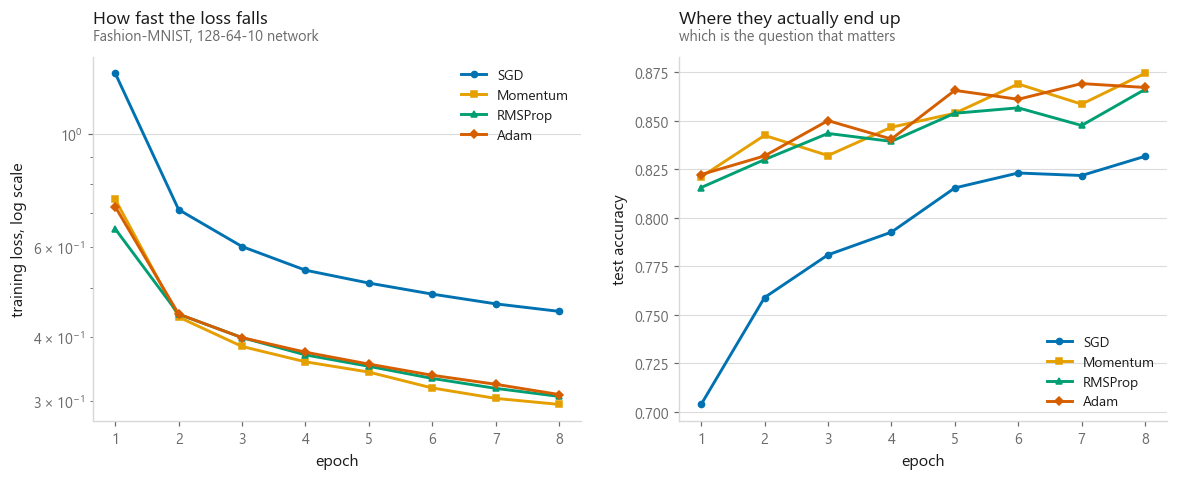

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))
for i, (name, history) in enumerate(results.items()):
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], marker=style.MARKERS[i], ms=4,
                 color=style.PALETTE[i], label=name)
    axes[1].plot(epochs, history["test_acc"], marker=style.MARKERS[i], ms=4,
                 color=style.PALETTE[i], label=name)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss, log scale")
axes[0].legend(fontsize=9)
style.title(axes[0], "How fast the loss falls", "Fashion-MNIST, 128-64-10 network")

axes[1].set_xlabel("epoch"); axes[1].set_ylabel("test accuracy")
axes[1].legend(fontsize=9, loc="lower right")
style.title(axes[1], "Where they actually end up", "which is the question that matters")

style.save(fig, FIG / "fig-02-real-network.png")

summary = pd.DataFrame({
    name: {"final train loss": h["train_loss"][-1],
           "best test accuracy": max(h["test_acc"]),
           "final test accuracy": h["test_acc"][-1],
           "epochs to reach 0.85": next((i + 1 for i, a in enumerate(h["test_acc"]) if a >= 0.85), None),
           "seconds": h["seconds"]}
    for name, h in results.items()}).T
print(summary.round(4).to_string())

## 5. Faster, or better?

The claim usually made for adaptive optimisers is that they converge faster. The
claim sometimes made is that they find better solutions. Those are different, and
the table above separates them: compare *epochs to reach 0.85* against *best test
accuracy*.

### Sensitivity to the learning rate

The more practical difference is how much care each one needs.

SGD: lr=0.005: 0.589  lr=0.02: 0.724  lr=0.05: 0.797  lr=0.2: 0.801  lr=0.5: 0.812


Adam: lr=0.0001: 0.791  lr=0.0005: 0.843  lr=0.001: 0.854  lr=0.005: 0.865  lr=0.02: 0.860
SGD: spread across the sweep = 0.223, best at lr=0.5 (0.812), monotone increasing: True
Adam: spread across the sweep = 0.073, best at lr=0.005 (0.865), monotone increasing: False


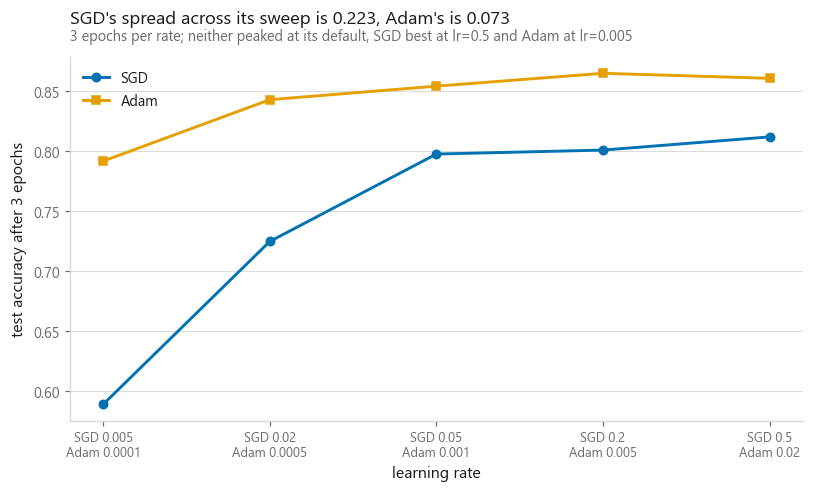

In [5]:
rates = {"SGD": [0.005, 0.02, 0.05, 0.2, 0.5],
         "Adam": [0.0001, 0.0005, 0.001, 0.005, 0.02]}
sensitivity = {}

for name, options in rates.items():
    scores = []
    for lr in options:
        model = build()
        loss_fn = nn.CrossEntropyLoss()
        optimiser = (torch.optim.SGD(model.parameters(), lr=lr) if name == "SGD"
                     else torch.optim.Adam(model.parameters(), lr=lr))
        for _ in range(3):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimiser.zero_grad()
                loss_fn(model(xb), yb).backward()
                optimiser.step()
        model.eval()
        correct = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                correct += (model(xb.to(device)).argmax(1) == yb.to(device)).sum().item()
        scores.append(correct / len(test_set))
    sensitivity[name] = scores
    print(f"{name}: " + "  ".join(f"lr={lr}: {s:.3f}" for lr, s in zip(options, scores)))

spreads = {name: max(s) - min(s) for name, s in sensitivity.items()}
peaks = {name: rates[name][int(np.argmax(s))] for name, s in sensitivity.items()}

fig, ax = plt.subplots(figsize=(8.6, 4.3))
for i, (name, scores) in enumerate(sensitivity.items()):
    ax.plot(range(len(scores)), scores, marker=style.MARKERS[i], color=style.PALETTE[i],
            label=name)

# Naming the positions "default" and "much too large" would be labelling my
# expectation rather than the run, and the run disagrees with it. The rates go on
# the axis instead.
ax.set_xticks(range(5),
              [f"SGD {a:g}\nAdam {b:g}" for a, b in zip(rates["SGD"], rates["Adam"])],
              fontsize=8.5)
ax.set_xlabel("learning rate")
ax.set_ylabel("test accuracy after 3 epochs")
ax.legend()
style.title(ax,
            f"SGD's spread across its sweep is {spreads['SGD']:.3f}, Adam's is "
            f"{spreads['Adam']:.3f}",
            f"3 epochs per rate; neither peaked at its default, SGD best at "
            f"lr={peaks['SGD']:g} and Adam at lr={peaks['Adam']:g}")
style.save(fig, FIG / "fig-03-sensitivity.png")

for name, scores in sensitivity.items():
    print(f"{name}: spread across the sweep = {spreads[name]:.3f}, "
          f"best at lr={peaks[name]:g} ({max(scores):.3f}), "
          f"monotone increasing: {all(b >= a for a, b in zip(scores, scores[1:]))}")

This is the real reason Adam is the default in most codebases. Not that it finds
better minima (the evidence for that is mixed and dataset-dependent), but that
**it works acceptably over a much wider range of learning rates.** SGD's spread
across its sweep is 0.223 and Adam's is 0.073, three times tighter. When you are
trying a new architecture and have no idea what rate to use, that is worth more
than a fraction of a percent of final accuracy.

Two things in that sweep did not go as I set it up to go, and the axis labels
were changed to say so.

**SGD never blew up.** Its accuracy rose monotonically across the whole sweep and
it scored its best, 0.812, at lr=0.5, the largest rate I tried. So the failure I
actually measured was rates too *small*, not too large, and I did not find the
divergence point at all. Labelling that last position "much too large" would have
been labelling my expectation, not the run.

**Adam did not peak at its default.** The best score was 0.865 at lr=0.005, above
the 0.854 at the 1e-3 that everyone reaches for first. The default is a good
starting guess, not an optimum, and a five-point sweep found something better in
three epochs.

Neither observation changes the headline, which is about spread rather than
peaks, and both are a reminder that a sweep only tells you about the range you
swept.

The counter-argument, worth knowing: well-tuned SGD with momentum still wins many
vision benchmarks, and models trained with it often generalise slightly better.
It also took the top accuracy in section 4 here. If you are going to tune
carefully anyway, SGD with momentum is not obsolete.

## Cheat sheet

| | |
|---|---|
| **Start with** | Adam at `lr=1e-3`. It is the default because it is forgiving |
| **Switch to SGD + momentum when** | You are tuning carefully, training a vision model, or chasing the last fraction of accuracy |
| **Momentum fixes** | The slow flat direction, by accumulating a consistent gradient. It damps zig-zag only when the rate is high enough to cause one; at lr=0.28 on my ravine it was the optimiser doing the zig-zagging, 15 crossings against SGD's 0 |
| **RMSProp fixes** | One learning rate for all parameters, by scaling each by its own gradient history |
| **Adam** | Both, plus bias correction for the cold start |
| **AdamW** | Adam with weight decay applied correctly. Prefer it when you use weight decay at all |
| **Watch out** | Learning rate still matters more than the optimiser. The 0.223 spread from the rate dwarfs the gaps between optimisers. Tune it first |

## What to remember

1. Every optimiser after SGD fixes a named failure: the slow flat direction, or
   one rate for all parameters. Both come from one rate serving two curvatures.
2. Momentum averages gradients; RMSProp scales by their squares; Adam does both.
3. Whether SGD zig-zags depends on the learning rate, not on SGD. Below
   $1/\text{curvature}$ its update in the steep direction is a monotone
   contraction and cannot change sign. At lr=0.28 it made 0 crossings and
   momentum made 15, and SGD still finished worst, because crawling loses to
   oscillating that covers ground.
4. Count the thing before describing it. The whole of SGD's 1.6376 final distance
   was in the flat direction, which is the opposite diagnosis to the one the
   picture is usually given.
5. On a real network the dramatic 2-D ordering mostly evaporates: momentum,
   RMSProp and Adam finished within 0.0083 of each other.
6. Adam's real advantage is tolerance to a badly chosen learning rate, spread
   0.073 against SGD's 0.223.
7. Tune the learning rate before you agonise over the optimiser, and check where
   your sweep actually peaked: mine peaked at the edge for SGD and off-default
   for Adam.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [07-06 Regularisation](../06-regularisation/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#Optimizers` `#Adam` `#SGD` `#Momentum` `#RMSProp`
`#PyTorch` `#MachineLearning` `#MLTutorial` `#GradientDescent`